In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score
import pandas as pd
import sys

sys.path.append('..')
from evaluation_functions import print_metrics, plot_decision_boundary, plot_roc, plot_confusion_matrix, measure_fit_time, ClassifierAbstraction

# Preparing synthetic data

In [87]:
RANDOM_STATE = 264034
N_SAMPLES = 2634

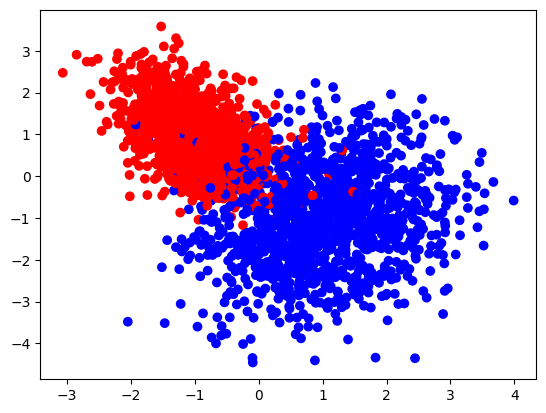

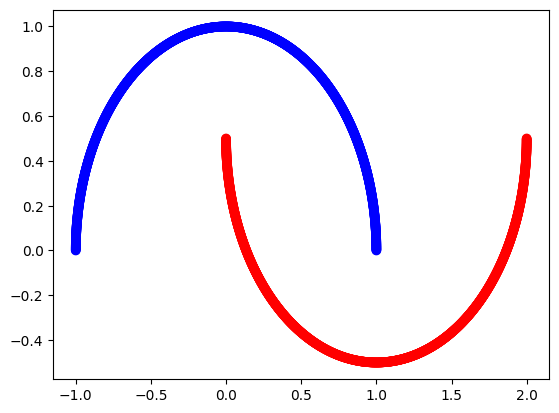

In [88]:
X_classification, y_classification = make_classification(n_samples = N_SAMPLES, n_clusters_per_class=1, n_features = 2, n_redundant = 0, n_informative = 2, random_state = RANDOM_STATE)
X_moons, y_moons = make_moons(n_samples = N_SAMPLES, random_state = RANDOM_STATE, noise=0)

plt.scatter(X_classification[:, 0], X_classification[:, 1], c=y_classification, cmap="bwr")
plt.show()
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="bwr")
plt.show()

# Implementation

In [89]:
class MyLogstisticRegression:
    def __init__(self):
        self.weights = []
        self.learning_rate_ = 0.1
    
    def sigmoid_(self, s):
        return 1/(1+np.exp(-s))

    def fit(self, X : np.ndarray, y : np.ndarray, epochs : int = 100, target_error : float | None = None) -> None:
        self.weights = np.zeros(X.shape[1])
        for epoch in range(epochs):
            for j, x in enumerate(X):
                y_output = self.predict_single(x)
                delta_weighs = -self.learning_rate_ * (y[j] - y_output) * self.sigmoid_(x @ self.weights) * (1 - self.sigmoid_(x.T @ self.weights)) * x
                self.weights -= delta_weighs

            if target_error is not None:
                current_error = np.mean((y - self.predict(X)) ** 2)
                if current_error <= target_error:
                    print(f"Converged at epoch {epoch} with error {current_error:.6f}")
                    break

    def predict_single(self, x):
        return self.sigmoid_(self.weights @ x)

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        return self.sigmoid_(X @ self.weights)

    def predict(self, X) -> np.ndarray:
        return (self.decision_function(X) >= 0.5).astype(int)

# Testing


── My Logistic Regression ──
Confusion matrix:
[[360  49]
 [ 69 313]]
Accuracy:       0.8508217446270544
Recall:         0.819371727748691
Specificity:    0.8801955990220048

── Sklearn Logistic Regression ──
Confusion matrix:
[[346  63]
 [ 53 329]]
Accuracy:       0.8533501896333755
Recall:         0.8612565445026178
Specificity:    0.8459657701711492


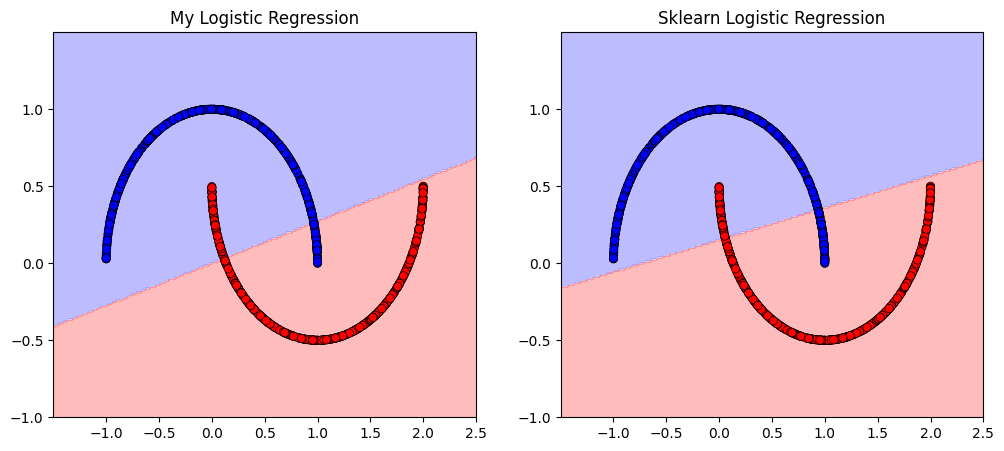

In [90]:
my_log_reg = MyLogstisticRegression()
sk_log_reg = LogisticRegression()

X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=RANDOM_STATE)

my_log_reg.fit(X_train_moons, y_train_moons)
sk_log_reg.fit(X_train_moons, y_train_moons)

print_metrics(my_log_reg, X_test_moons, y_test_moons, "My Logistic Regression")
print_metrics(sk_log_reg, X_test_moons, y_test_moons, "Sklearn Logistic Regression")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(my_log_reg, X_test_moons, y_test_moons, axes[0], "My Logistic Regression")
plot_decision_boundary(sk_log_reg, X_test_moons, y_test_moons, axes[1], "Sklearn Logistic Regression")
plt.show()


── My Logistic Regression ──
Confusion matrix:
[[356  24]
 [ 18 393]]
Accuracy:       0.9469026548672567
Recall:         0.9562043795620438
Specificity:    0.9368421052631579

── Sklearn Logistic Regression ──
Confusion matrix:
[[359  21]
 [ 27 384]]
Accuracy:       0.9393173198482933
Recall:         0.9343065693430657
Specificity:    0.9447368421052632


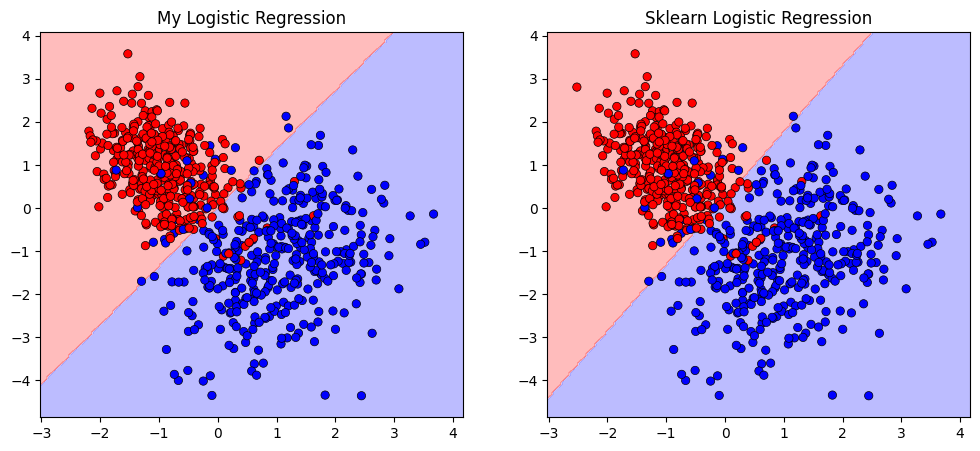

In [91]:
my_log_reg_clf = MyLogstisticRegression()
sk_log_reg_clf = LogisticRegression()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification, test_size=0.3, random_state=RANDOM_STATE)

my_log_reg_clf.fit(X_train_clf, y_train_clf)
sk_log_reg_clf.fit(X_train_clf, y_train_clf)

print_metrics(my_log_reg_clf, X_test_clf, y_test_clf, "My Logistic Regression")
print_metrics(sk_log_reg_clf, X_test_clf, y_test_clf, "Sklearn Logistic Regression")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(my_log_reg_clf, X_test_clf, y_test_clf, axes[0], "My Logistic Regression")
plot_decision_boundary(sk_log_reg_clf, X_test_clf, y_test_clf, axes[1], "Sklearn Logistic Regression")
plt.show()

____________________

# Real dataset

### Loading

In [92]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")

print("Path to dataset files:", path)

df = pd.read_csv(f"{path}/weatherAUS.csv")
df.head()

Path to dataset files: C:\Users\MatG\.cache\kagglehub\datasets\jsphyg\weather-dataset-rattle-package\versions\2


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


### Preprocessing

Cleaning data

In [93]:
# Dropping columns with missing data over 10%
columns_to_drop = []
for column in df.columns:
    # print("___________")
    # print(f"{column}: {df[column].isna().sum()} missing values")
    # print(f"{column}: {df[column].isna().sum()/len(df[column]) * 100.:2f}% missing values")
    if df[column].isna().sum()/len(df[column]) * 100. > 10:
        columns_to_drop.append(column)

print(df.columns)
df_after_drop = df.drop(columns=columns_to_drop)
print(df_after_drop.columns)
print(f"Dropped columns: {columns_to_drop}")
print(len(df_after_drop))

# Also drop rows with empty RainTommorow:
df_after_drop = df_after_drop.dropna(subset=['RainTomorrow'])
df_after_drop.head(3)
print(len(df_after_drop))

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='str')
Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir',
       'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Temp9am', 'Temp3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')
Dropped columns: ['Evaporation', 'Sunshine', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm']
145460
142193


In [94]:
df_after_drop[df_after_drop.isna().any(axis=1)]

,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
15,2008-12-16,Albury,9.8,27.7,NaN,WNW,50.0,NaN,WNW,NaN,22.0,50.0,28.0,17.3,26.2,NaN,No
26,2008-12-27,Albury,16.9,33.0,0.0,WSW,57.0,NaN,W,0.0,26.0,41.0,28.0,26.6,31.2,No,No
64,2009-02-03,Albury,21.5,37.7,0.0,NaN,NaN,N,NaN,13.0,9.0,51.0,21.0,27.2,36.2,No,No
65,2009-02-04,Albury,21.7,36.9,0.0,NaN,NaN,NaN,NaN,11.0,11.0,53.0,26.0,25.5,35.2,No,No
75,2009-02-14,Albury,12.4,29.2,0.0,NE,39.0,S,NaN,7.0,0.0,37.0,18.0,18.3,28.5,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145316,2017-02-02,Uluru,27.5,36.5,0.0,NaN,NaN,ESE,E,13.0,24.0,50.0,34.0,29.0,35.4,No,Yes
145323,2017-02-09,Uluru,25.6,40.6,0.2,ENE,56.0,NaN,N,0.0,11.0,47.0,27.0,32.0,38.6,No,No
145336,2017-02-22,Uluru,16.1,38.0,NaN,SSW,35.0,SSW,W,22.0,17.0,30.0,16.0,27.7,36.4,NaN,No
145422,2017-05-19,Uluru,4.3,22.4,0.0,ENE,26.0,NaN,N,0.0,7.0,71.0,33.0,10.9,21.3,No,No


In [95]:
# Missing data imputation
# Categorical data: WindGustDir, WindDir9am, WindDir3pm, RainToday
# print(df_after_drop.select_dtypes('str').columns)
categorical_columns_for_imputation = ["WindGustDir", "WindDir9am", "WindDir3pm", "RainToday"]
for column in df_after_drop.columns:
    if df_after_drop[column].isna().sum() > 0:
        print(column)
        if column in categorical_columns_for_imputation:
            df_after_drop[column] = df_after_drop[column].fillna(df_after_drop[column].mode()[0])
        else:
            df_after_drop[column] = df_after_drop[column].fillna(df_after_drop[column].mean())

MinTemp
MaxTemp
Rainfall
WindGustDir
WindGustSpeed
WindDir9am
WindDir3pm
WindSpeed9am
WindSpeed3pm
Humidity9am
Humidity3pm
Temp9am
Temp3pm
RainToday


In [96]:
df_X = df_after_drop.drop(columns=['RainTomorrow'])
df_y = df_after_drop['RainTomorrow'].map({"Yes": 1, "No": 0})
df_X.head()
# df_after_drop[df_after_drop['RainTomorrow'].isna()]
print(len(df_after_drop))
df_after_drop[df_after_drop.isna().any(axis=1)]

142193


,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Temp9am,Temp3pm,RainToday,RainTomorrow


In [97]:
df_y.unique()

array([0, 1])

Winsorizing data

In [98]:
numerical_cols = df_X.select_dtypes(include=['float64', 'int64']).columns
for column in numerical_cols:
    print(f"{column}'s min before: {df_X[column].min()}")
    print(f"{column}'s max before: {df_X[column].max()}")
    q1 =  df_X[column].quantile(0.25)
    q3 =  df_X[column].quantile(0.75)
    iqr = q3 - q1
    print(f"Bounds: {q1 - 1.5 * iqr} {q3 + 1.5 * iqr}")
    df_X[column] = df_X[column].clip(lower = q1 - 1.5 * iqr, upper = q3 + 1.5 * iqr) 
    print(f"{column}'s min after: {df_X[column].min()}")
    print(f"{column}'s max after: {df_X[column].max()}")

MinTemp's min before: -8.5
MinTemp's max before: 33.9
Bounds: -6.200000000000001 30.6
MinTemp's min after: -6.200000000000001
MinTemp's max after: 30.6
MaxTemp's min before: -4.8
MaxTemp's max before: 48.1
Bounds: 2.4499999999999975 43.65
MaxTemp's min after: 2.4499999999999975
MaxTemp's max after: 43.65
Rainfall's min before: 0.0
Rainfall's max before: 371.0
Bounds: -1.2000000000000002 2.0
Rainfall's min after: 0.0
Rainfall's max after: 2.0
WindGustSpeed's min before: 6.0
WindGustSpeed's max before: 135.0
Bounds: 8.5 68.5
WindGustSpeed's min after: 8.5
WindGustSpeed's max after: 68.5
WindSpeed9am's min before: 0.0
WindSpeed9am's max before: 130.0
Bounds: -11.0 37.0
WindSpeed9am's min after: 0.0
WindSpeed9am's max after: 37.0
WindSpeed3pm's min before: 0.0
WindSpeed3pm's max before: 87.0
Bounds: -3.5 40.5
WindSpeed3pm's min after: 0.0
WindSpeed3pm's max after: 40.5
Humidity9am's min before: 0.0
Humidity9am's max before: 100.0
Bounds: 18.0 122.0
Humidity9am's min after: 18.0
Humidity9am

One-hot encoding categorical data

In [99]:
print(len(df_X.columns))
df_X = pd.get_dummies(df_X, columns=categorical_columns_for_imputation)
df_X.head(2)


16


,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_No,RainToday_Yes
0,2008-12-01,Albury,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,...,False,False,False,False,False,False,True,False,True,False
1,2008-12-02,Albury,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,...,False,False,False,False,False,False,False,True,True,False


In [100]:
print(df_X.columns)
new_categorical_cols = df_X.select_dtypes(include=['bool']).columns
new_categorical_cols

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Temp9am',
       'Temp3pm', 'WindGustDir_E', 'WindGustDir_ENE', 'WindGustDir_ESE',
       'WindGustDir_N', 'WindGustDir_NE', 'WindGustDir_NNE', 'WindGustDir_NNW',
       'WindGustDir_NW', 'WindGustDir_S', 'WindGustDir_SE', 'WindGustDir_SSE',
       'WindGustDir_SSW', 'WindGustDir_SW', 'WindGustDir_W', 'WindGustDir_WNW',
       'WindGustDir_WSW', 'WindDir9am_E', 'WindDir9am_ENE', 'WindDir9am_ESE',
       'WindDir9am_N', 'WindDir9am_NE', 'WindDir9am_NNE', 'WindDir9am_NNW',
       'WindDir9am_NW', 'WindDir9am_S', 'WindDir9am_SE', 'WindDir9am_SSE',
       'WindDir9am_SSW', 'WindDir9am_SW', 'WindDir9am_W', 'WindDir9am_WNW',
       'WindDir9am_WSW', 'WindDir3pm_E', 'WindDir3pm_ENE', 'WindDir3pm_ESE',
       'WindDir3pm_N', 'WindDir3pm_NE', 'WindDir3pm_NNE', 'WindDir3pm_NNW',
       'WindDir3pm_NW', 'WindDir3pm_S', 'WindDir3pm_SE', 'WindDir3pm_SSE

Index(['WindGustDir_E', 'WindGustDir_ENE', 'WindGustDir_ESE', 'WindGustDir_N',
       'WindGustDir_NE', 'WindGustDir_NNE', 'WindGustDir_NNW',
       'WindGustDir_NW', 'WindGustDir_S', 'WindGustDir_SE', 'WindGustDir_SSE',
       'WindGustDir_SSW', 'WindGustDir_SW', 'WindGustDir_W', 'WindGustDir_WNW',
       'WindGustDir_WSW', 'WindDir9am_E', 'WindDir9am_ENE', 'WindDir9am_ESE',
       'WindDir9am_N', 'WindDir9am_NE', 'WindDir9am_NNE', 'WindDir9am_NNW',
       'WindDir9am_NW', 'WindDir9am_S', 'WindDir9am_SE', 'WindDir9am_SSE',
       'WindDir9am_SSW', 'WindDir9am_SW', 'WindDir9am_W', 'WindDir9am_WNW',
       'WindDir9am_WSW', 'WindDir3pm_E', 'WindDir3pm_ENE', 'WindDir3pm_ESE',
       'WindDir3pm_N', 'WindDir3pm_NE', 'WindDir3pm_NNE', 'WindDir3pm_NNW',
       'WindDir3pm_NW', 'WindDir3pm_S', 'WindDir3pm_SE', 'WindDir3pm_SSE',
       'WindDir3pm_SSW', 'WindDir3pm_SW', 'WindDir3pm_W', 'WindDir3pm_WNW',
       'WindDir3pm_WSW', 'RainToday_No', 'RainToday_Yes'],
      dtype='str')

Turning date into sin cos cyclical encoding

In [101]:
# Splitting into Day and Month. Discarding Year
df_X['Date'] = pd.to_datetime(df_X['Date'])
df_X['DayOfYear'] = df_X['Date'].dt.dayofyear
df_X['Month'] = df_X['Date'].dt.month

df_X['Day_sin'] = df_X['DayOfYear'].apply(lambda x : np.sin(x / 365 * 2 * np.pi))
df_X['Day_cos'] = df_X['DayOfYear'].apply(lambda x : np.cos(x / 365 * 2 * np.pi))
df_X['Month_sin'] = df_X['Month'].apply(lambda x : np.sin(x / 12 * 2 * np.pi))
df_X['Month_cos'] = df_X['Month'].apply(lambda x : np.cos(x / 12 * 2 * np.pi))

In [102]:
print(df_X.columns)
df_X = df_X.drop(columns=['Date', 'DayOfYear', 'Month'])
print(df_X.columns)
df_X.head(2)

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Temp9am',
       'Temp3pm', 'WindGustDir_E', 'WindGustDir_ENE', 'WindGustDir_ESE',
       'WindGustDir_N', 'WindGustDir_NE', 'WindGustDir_NNE', 'WindGustDir_NNW',
       'WindGustDir_NW', 'WindGustDir_S', 'WindGustDir_SE', 'WindGustDir_SSE',
       'WindGustDir_SSW', 'WindGustDir_SW', 'WindGustDir_W', 'WindGustDir_WNW',
       'WindGustDir_WSW', 'WindDir9am_E', 'WindDir9am_ENE', 'WindDir9am_ESE',
       'WindDir9am_N', 'WindDir9am_NE', 'WindDir9am_NNE', 'WindDir9am_NNW',
       'WindDir9am_NW', 'WindDir9am_S', 'WindDir9am_SE', 'WindDir9am_SSE',
       'WindDir9am_SSW', 'WindDir9am_SW', 'WindDir9am_W', 'WindDir9am_WNW',
       'WindDir9am_WSW', 'WindDir3pm_E', 'WindDir3pm_ENE', 'WindDir3pm_ESE',
       'WindDir3pm_N', 'WindDir3pm_NE', 'WindDir3pm_NNE', 'WindDir3pm_NNW',
       'WindDir3pm_NW', 'WindDir3pm_S', 'WindDir3pm_SE', 'WindDir3pm_SSE

,Location,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Temp9am,...,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_No,RainToday_Yes,Day_sin,Day_cos,Month_sin,Month_cos
0,Albury,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,16.9,...,False,False,True,False,True,False,-0.478734,0.877960,-2.449294e-16,1.0
1,Albury,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,17.2,...,False,False,False,True,True,False,-0.463550,0.886071,-2.449294e-16,1.0


sanity check to see if encoding is correct

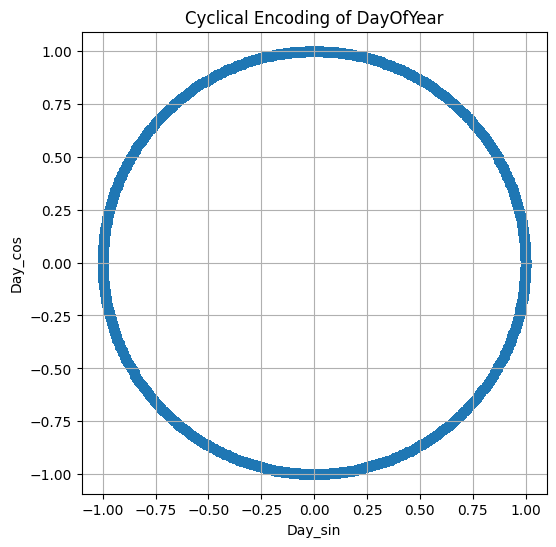

In [103]:
plt.figure(figsize=(6,6))
plt.scatter(df_X['Day_sin'], df_X['Day_cos'])
plt.xlabel('Day_sin')
plt.ylabel('Day_cos')
plt.title('Cyclical Encoding of DayOfYear')
plt.axis('equal')
plt.grid()
plt.show()

Spliting into regions

In [104]:
'''
key: Region name as in datset
value: Tuple of (X_region, y_region)
'''
region_dataset_dictionary = {} 

locations = df_X['Location'].unique()

for location in locations:
    location_mask = df_X['Location'] == location
    X_region = df_X[location_mask]
    y_region = df_y[location_mask]
    region_dataset_dictionary[location] = (X_region, y_region)

region_dataset_dictionary['Australia'] = (df_X, df_y)

# Training and testing for each region

In [105]:
from sklearn.dummy import DummyClassifier

regional_models = {}
regional_scores = {}
regional_test_sets = []

Normalizing numerical data per region and finding best one based on f1 score

In [106]:
for region in locations:
    X_region, y_region = region_dataset_dictionary[region]

    X_region = X_region.drop(columns=['Location'])

    X_train, X_test, y_train, y_test = train_test_split(
        X_region, y_region, test_size=0.3, random_state=RANDOM_STATE, stratify=y_region
    )

    scaler = MinMaxScaler()

    X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

    # Train model
    model = LogisticRegression(max_iter=1000)
    # print(X_train.columns)
    X_train_numeric = X_train.to_numpy(dtype=np.float64)
    y_train_numeric = y_train.to_numpy(dtype=np.float64)
    X_test_numeric = X_test.to_numpy(dtype=np.float64)
    y_test_numeric = y_test.to_numpy(dtype=np.float64)

    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    recall = recall_score(y_test, y_pred)
    print_metrics(model, X_test, y_test, region)

    # Store
    regional_models[region] = (model, scaler)
    regional_scores[region] = recall

    regional_test_sets.append((X_test, y_test))

    print(f"{region}: {recall:.4f}")


── Albury ──
Confusion matrix:
[[691  27]
 [ 97  89]]
Accuracy:       0.8628318584070797
Recall:         0.478494623655914
Specificity:    0.9623955431754875
Albury: 0.4785

── BadgerysCreek ──
Confusion matrix:
[[682  22]
 [ 85  90]]
Accuracy:       0.8782707622298066
Recall:         0.5142857142857142
Specificity:    0.96875
BadgerysCreek: 0.5143

── Cobar ──
Confusion matrix:
[[767  14]
 [ 69  47]]
Accuracy:       0.907469342251951
Recall:         0.4051724137931034
Specificity:    0.9820742637644047
Cobar: 0.4052

── CoffsHarbour ──
Confusion matrix:
[[575  50]
 [121 140]]
Accuracy:       0.8069977426636569
Recall:         0.5363984674329502
Specificity:    0.92
CoffsHarbour: 0.5364

── Moree ──
Confusion matrix:
[[719  20]
 [ 56  62]]
Accuracy:       0.911318553092182
Recall:         0.5254237288135594
Specificity:    0.972936400541272
Moree: 0.5254

── Newcastle ──
Confusion matrix:
[[613  55]
 [153  66]]
Accuracy:       0.7655016910935738
Recall:         0.3013698630136986
Spec

Selecting best one and comparing it to my implementation

In [107]:
best_region = max(regional_scores, key=lambda key: regional_scores[key])
print(f"Best region saved: {best_region}")

best_model, best_scaler = regional_models[best_region]
X_region, y_region = region_dataset_dictionary[best_region]

X_region = X_region.drop(columns=['Location'])

X_region_scaled = X_region.copy()
X_region_scaled[numerical_cols] = best_scaler.transform(X_region[numerical_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X_region_scaled, y_region, test_size=0.3, random_state=RANDOM_STATE, stratify=y_region
)

# Evaluate best sklearn model on the test set
print_metrics(best_model, X_test, y_test, f"Best model ({best_region})")

Best region saved: Cairns

── Best model (Cairns) ──
Confusion matrix:
[[532  80]
 [ 90 195]]
Accuracy:       0.810479375696767
Recall:         0.6842105263157895
Specificity:    0.869281045751634


Comparing it to mine

In [108]:
_, best_scaler = regional_models[best_region]
X_region, y_region = region_dataset_dictionary[best_region]

X_region = X_region.drop(columns=['Location'])

X_region_scaled = X_region.copy()
X_region_scaled[numerical_cols] = best_scaler.transform(X_region[numerical_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X_region_scaled, y_region, test_size=0.3, random_state=RANDOM_STATE, stratify=y_region
)

X_train_numeric = X_train.to_numpy(dtype=np.float64)
y_train_numeric = y_train.to_numpy(dtype=np.float64)
X_test_numeric = X_test.to_numpy(dtype=np.float64)
y_test_numeric = y_test.to_numpy(dtype=np.float64)

my_model = MyLogstisticRegression()
sk_model = LogisticRegression(max_iter=1000)

my_model.fit(X_train_numeric, y_train_numeric)
sk_model.fit(X_train_numeric, y_train_numeric)

print_metrics(my_model, X_test_numeric, y_test_numeric, "My Logistic Regression")
print_metrics(sk_model, X_test_numeric, y_test_numeric, "Sklearn Logistic Regression")


── My Logistic Regression ──
Confusion matrix:
[[538  74]
 [ 95 190]]
Accuracy:       0.8115942028985508
Recall:         0.6666666666666666
Specificity:    0.8790849673202614

── Sklearn Logistic Regression ──
Confusion matrix:
[[532  80]
 [ 90 195]]
Accuracy:       0.810479375696767
Recall:         0.6842105263157895
Specificity:    0.869281045751634


# Testing for national dataset

In [109]:
X_national_test = df_X
y_national_test = df_y

In [110]:
regional_national_scores = {}

for region, (model, scaler) in regional_models.items():
    X_test_region = X_national_test.drop(columns=['Location'])
    
    X_test_region[numerical_cols] = scaler.transform(X_test_region[numerical_cols])
    
    y_pred_sklearn = model.predict(X_test_region)
    accuracy = accuracy_score(y_national_test, y_pred_sklearn)
    
    print_metrics(model, X_test_region, y_national_test, f"Region: {region}")

    regional_national_scores[region] = accuracy


── Region: Albury ──
Confusion matrix:
[[85515 24801]
 [11275 20602]]
Accuracy:       0.746288495214251
Recall:         0.6462967029519716
Specificity:    0.775182203850756

── Region: BadgerysCreek ──
Confusion matrix:
[[102054   8262]
 [ 17131  14746]]
Accuracy:       0.8214187758891085
Recall:         0.462590582551683
Specificity:    0.9251060589579028

── Region: Cobar ──
Confusion matrix:
[[97623 12693]
 [15216 16661]]
Accuracy:       0.8037245152714972
Recall:         0.5226652445336764
Specificity:    0.8849396279778092

── Region: CoffsHarbour ──
Confusion matrix:
[[95752 14564]
 [14294 17583]]
Accuracy:       0.7970504877173982
Recall:         0.5515889199109075
Specificity:    0.8679792595815656

── Region: Moree ──
Confusion matrix:
[[99846 10470]
 [16073 15804]]
Accuracy:       0.8133311766402003
Recall:         0.4957806568999592
Specificity:    0.9050908299793321

── Region: Newcastle ──
Confusion matrix:
[[101196   9120]
 [ 17663  14214]]
Accuracy:       0.811643329840

best one:

In [111]:
best_national_region = max(regional_national_scores, key=regional_national_scores.get)
best_national_accuracy = regional_national_scores[best_national_region]

print(f"Best regional model on national test set: {best_national_region} with accuracy {best_national_accuracy:.4f}")

Best regional model on national test set: Wollongong with accuracy 0.8229


dummy classifier:

In [112]:
dummy = DummyClassifier(strategy='most_frequent')
X_dummy = X_national_test.drop(columns=['Location'], errors='ignore')
dummy.fit(X_dummy, y_national_test)
dummy_accuracy = dummy.score(X_dummy, y_national_test)
print(f"DummyClassifier accuracy on national test set: {dummy_accuracy:.4f}")

DummyClassifier accuracy on national test set: 0.7758
